## **SUPERSTORE SALES ANALYST**

### 🎯 Objectives:
- Analyze the company's sales performance according to the following aspects:

    - Products, customers, geography, time, shipping method.

- Find hidden insights to support decision making:

    - Which customer groups bring in the most profit?

    - Which categories should be cut due to losses?

    - Which Shipping Mode is ineffective?

    - Best time of year to sell?

In [1]:
#import libary
import pandas as pd
import numpy as np
import datetime
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
import plotly.express as px
from matplotlib.colors import ListedColormap
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.tree import DecisionTreeClassifier

### **1.Load data**

In [ ]:
df = pd.read_csv("superstore_sales.csv")

# Remove "," in columns (sales, shipping cost, profit)
cols_to_clean = ['sales', 'profit', 'shipping_cost']
for col in cols_to_clean:
    df[col] = df[col].replace({',': ''}, regex=True).astype(float)

# Save file csv
df.to_csv("superstore_sales_clean.csv", index=False)

In [2]:
df = pd.read_csv('superstore_sales_clean.csv')

In [3]:
df.head()

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year
0,AG-2011-2040,1/1/2011,1/6/2011,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,Office Supplies,Storage,"Tenex Lockers, Blue",408.0,2,0.0,106.140,35.46,Medium,2011
1,IN-2011-47883,1/1/2011,1/8/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Office Supplies,Supplies,"Acme Trimmer, High Speed",120.0,3,0.1,36.036,9.72,Medium,2011
2,HU-2011-1220,1/1/2011,1/5/2011,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,Office Supplies,Storage,"Tenex Box, Single Width",66.0,4,0.0,29.640,8.17,High,2011
3,IT-2011-3647632,1/1/2011,1/5/2011,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,...,Office Supplies,Paper,"Enermax Note Cards, Premium",45.0,3,0.5,-26.055,4.82,High,2011
4,IN-2011-47883,1/1/2011,1/8/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Furniture,Furnishings,"Eldon Light Bulb, Duo Pack",114.0,5,0.1,37.770,4.70,Medium,2011


### **2.Data cleaning**

In [4]:
# columns name of table
df.columns

Index(['order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_name',
       'segment', 'state', 'country', 'market', 'region', 'product_id',
       'category', 'sub_category', 'product_name', 'sales', 'quantity',
       'discount', 'profit', 'shipping_cost', 'order_priority', 'year'],
      dtype='object')

In [5]:
# info of data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        51290 non-null  object 
 1   order_date      51290 non-null  object 
 2   ship_date       51290 non-null  object 
 3   ship_mode       51290 non-null  object 
 4   customer_name   51290 non-null  object 
 5   segment         51290 non-null  object 
 6   state           51290 non-null  object 
 7   country         51290 non-null  object 
 8   market          51290 non-null  object 
 9   region          51290 non-null  object 
 10  product_id      51290 non-null  object 
 11  category        51290 non-null  object 
 12  sub_category    51290 non-null  object 
 13  product_name    51290 non-null  object 
 14  sales           51290 non-null  float64
 15  quantity        51290 non-null  int64  
 16  discount        51290 non-null  float64
 17  profit          51290 non-null 

In [6]:
#Get categorical columns and numerical columns
categorical_cols = [feature for feature in df.columns if df[feature].dtype == 'O']

numerical_cols = [feature for feature in df.columns if df[feature].dtype != 'O']

print('Categorical columns:' ,categorical_cols, "\nNumerical columns: ", numerical_cols)

Categorical columns: ['order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_name', 'segment', 'state', 'country', 'market', 'region', 'product_id', 'category', 'sub_category', 'product_name', 'order_priority'] 
Numerical columns:  ['sales', 'quantity', 'discount', 'profit', 'shipping_cost', 'year']


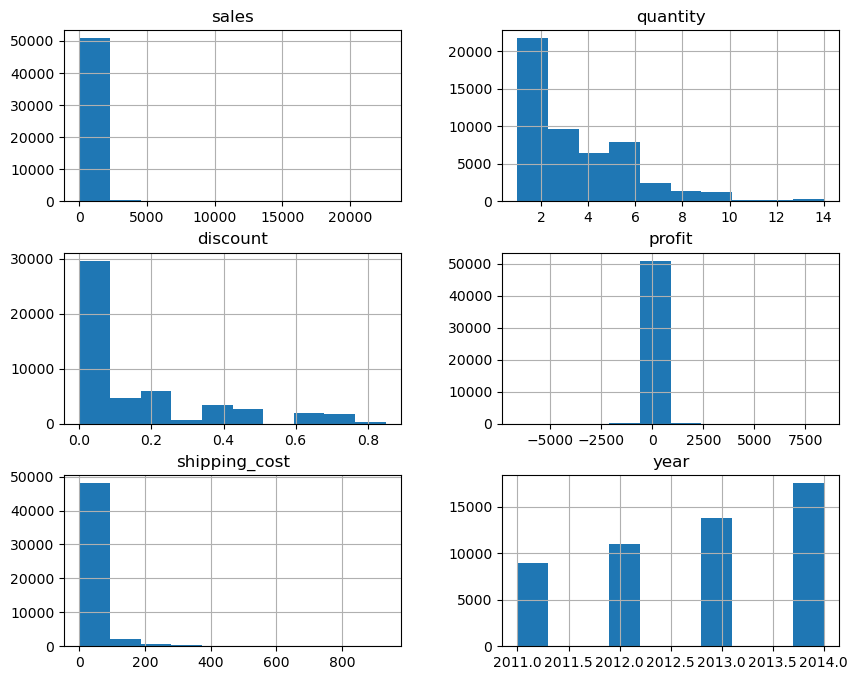

In [7]:
df.hist(figsize=(10, 8))
plt.show()

In [8]:
df.shape

(51290, 21)

In [9]:
df.describe()

,sales,quantity,discount,profit,shipping_cost,year
count,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000
mean,246.498440,3.476545,0.142908,28.641740,26.375915,2012.777208
std,487.567175,2.278766,0.212280,174.424113,57.296804,1.098931
min,0.000000,1.000000,0.000000,-6599.978000,0.000000,2011.000000
25%,31.000000,2.000000,0.000000,0.000000,2.610000,2012.000000
50%,85.000000,3.000000,0.000000,9.240000,7.790000,2013.000000
75%,251.000000,5.000000,0.200000,36.810000,24.450000,2014.000000
max,22638.000000,14.000000,0.850000,8399.976000,933.570000,2014.000000


In [10]:
# check data type of columns
df.dtypes

order_id           object
order_date         object
ship_date          object
ship_mode          object
customer_name      object
segment            object
state              object
country            object
market             object
region             object
product_id         object
category           object
sub_category       object
product_name       object
sales             float64
quantity            int64
discount          float64
profit            float64
shipping_cost     float64
order_priority     object
year                int64
dtype: object

In [11]:
# check for null value
df.isnull().sum()

order_id          0
order_date        0
ship_date         0
ship_mode         0
customer_name     0
segment           0
state             0
country           0
market            0
region            0
product_id        0
category          0
sub_category      0
product_name      0
sales             0
quantity          0
discount          0
profit            0
shipping_cost     0
order_priority    0
year              0
dtype: int64

In [12]:
# check and drop for duplicate value
df.duplicated().sum()
df.drop_duplicates(inplace=True)

In [13]:
# remove nal value
df = df.dropna(axis=0)

In [14]:
# check value outlier
Q25 = np.quantile(df['sales'], q= 0.25)
Q75 = np.quantile(df['sales'], q = 0.75)
IQR = Q75 - Q25
cut_off = IQR * 1.5

print('Number of Sales Lower Outliers: ', df[df['sales'] <= (Q25 - cut_off)]['sales'].count())
print('Number of Sales Upper Outliers: ', df[df['sales'] >= (Q75 + cut_off)]['sales'].count())


Number of Sales Lower Outliers:  0
Number of Sales Upper Outliers:  5664


In [15]:
# drop rows where ship date is earlier than order date
df = df[df['ship_date'] >= df['order_date']]

### **3.Exploratory Data Analysis (EDA)**

In [16]:
#Convert date data type
df['order_date'] = pd.to_datetime(df['order_date'])
df['ship_date'] = pd.to_datetime(df['ship_date'])

In [17]:
#Create delivery time
df['delivery_days'] = (df['ship_date'] - df['order_date']).dt.days

df['month'] = df['order_date'].dt.month
df['month_year'] = df['order_date'].dt.to_period('M').astype(str)

In [18]:
print("\nDataFrame Info After Date Conversion:")
df.info()


DataFrame Info After Date Conversion:
<class 'pandas.core.frame.DataFrame'>
Index: 43239 entries, 0 to 51277
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   order_id        43239 non-null  object        
 1   order_date      43239 non-null  datetime64[ns]
 2   ship_date       43239 non-null  datetime64[ns]
 3   ship_mode       43239 non-null  object        
 4   customer_name   43239 non-null  object        
 5   segment         43239 non-null  object        
 6   state           43239 non-null  object        
 7   country         43239 non-null  object        
 8   market          43239 non-null  object        
 9   region          43239 non-null  object        
 10  product_id      43239 non-null  object        
 11  category        43239 non-null  object        
 12  sub_category    43239 non-null  object        
 13  product_name    43239 non-null  object        
 14  sales           4323

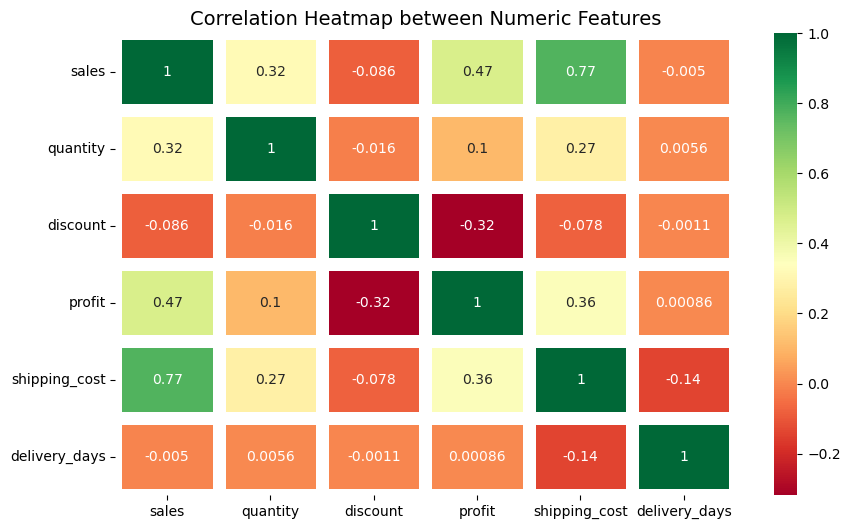

In [19]:
# Correlation matrix between columns of numbers
numeric_cols = ['sales', 'quantity', 'discount', 'profit', 'shipping_cost', 'delivery_days']
corr_matrix = df[numeric_cols].corr()

# draw heatmap
plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix, annot =True, cmap = 'RdYlGn', lw =8, linecolor='white')
plt.title('Correlation Heatmap between Numeric Features', fontsize=14)
plt.show()

##### **Analysis**:
- Sales and profit (0.47): High sales often go hand in with high profit, indicating that large transactions can yield good finacial performance.
- Shipping_cost and sales (0.77): high shipping cost often associted with high sales, possibly due to shipping large quantities or remote area.
- Discount và profit (-0.32): Discounts tend to reduce profits, discount strategy needs to be reconsidered.

In [20]:
df = df.sort_values(by ='order_date')
df

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,sales,quantity,discount,profit,shipping_cost,order_priority,year,delivery_days,month,month_year
0,AG-2011-2040,2011-01-01,2011-01-06,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,408.0,2,0.0,106.140,35.46,Medium,2011,5,1,2011-01
1,IN-2011-47883,2011-01-01,2011-01-08,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,120.0,3,0.1,36.036,9.72,Medium,2011,7,1,2011-01
2,HU-2011-1220,2011-01-01,2011-01-05,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,66.0,4,0.0,29.640,8.17,High,2011,4,1,2011-01
3,IT-2011-3647632,2011-01-01,2011-01-05,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,...,45.0,3,0.5,-26.055,4.82,High,2011,4,1,2011-01
4,IN-2011-47883,2011-01-01,2011-01-08,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,114.0,5,0.1,37.770,4.70,Medium,2011,7,1,2011-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51204,EG-2014-4970,2014-12-30,2014-12-30,Same Day,Gary McGarr,Consumer,Al Qahirah,Egypt,Africa,Africa,...,18.0,1,0.0,3.300,3.26,High,2014,0,12,2014-12
51211,TU-2014-7130,2014-12-30,2014-12-31,First Class,Mitch Gastineau,Corporate,Aydin,Turkey,EMEA,EMEA,...,166.0,2,0.6,-141.036,2.26,High,2014,1,12,2014-12
51242,MX-2014-141712,2014-12-31,2014-12-31,Same Day,Rick Bensley,Home Office,Managua,Nicaragua,LATAM,Central,...,78.0,2,0.0,35.920,25.16,Critical,2014,0,12,2014-12
51238,MX-2014-141712,2014-12-31,2014-12-31,Same Day,Rick Bensley,Home Office,Managua,Nicaragua,LATAM,Central,...,120.0,4,0.0,30.000,43.35,Critical,2014,0,12,2014-12


##### **Overview**

In [21]:
print('Total sales: ',df['sales'].sum())
print('Total profit: ', df['profit'].sum())
print('Total number of orders: ', df['order_id'].nunique())
print('Total quantity sola: ', df['quantity'].sum())
print('Average shipping days: ', df['delivery_days'].mean())

Total sales:  10728092.0
Total profit:  1251355.0871799998
Total number of orders:  21176
Total quantity sola:  150420
Average shipping days:  3.833784315085918


### **4. Data Analysis**

#### **Sales & Profit by Month**

In [22]:
# monthly revenue and profit
df['month_name'] = df['order_date'].dt.strftime('%b')
monthly_summary = df.groupby('month_name')[['sales', 'profit']].sum().reset_index().round(2)
monthly_summary['profit_margin'] = monthly_summary['profit'] / monthly_summary['sales'] * 100
monthly_summary

,month_name,sales,profit,profit_margin
0,Apr,605272.0,68003.63,11.235218
1,Aug,1148857.0,130122.47,11.326255
2,Dec,1224787.0,135039.31,11.025534
3,Feb,470346.0,65531.81,13.932681
4,Jan,582107.0,65614.01,11.271813
5,Jul,657692.0,65593.30,9.973255
6,Jun,1117079.0,132091.17,11.824694
7,Mar,697572.0,83805.13,12.013832
8,May,778658.0,89111.87,11.444289
9,Nov,1366657.0,155915.08,11.408501


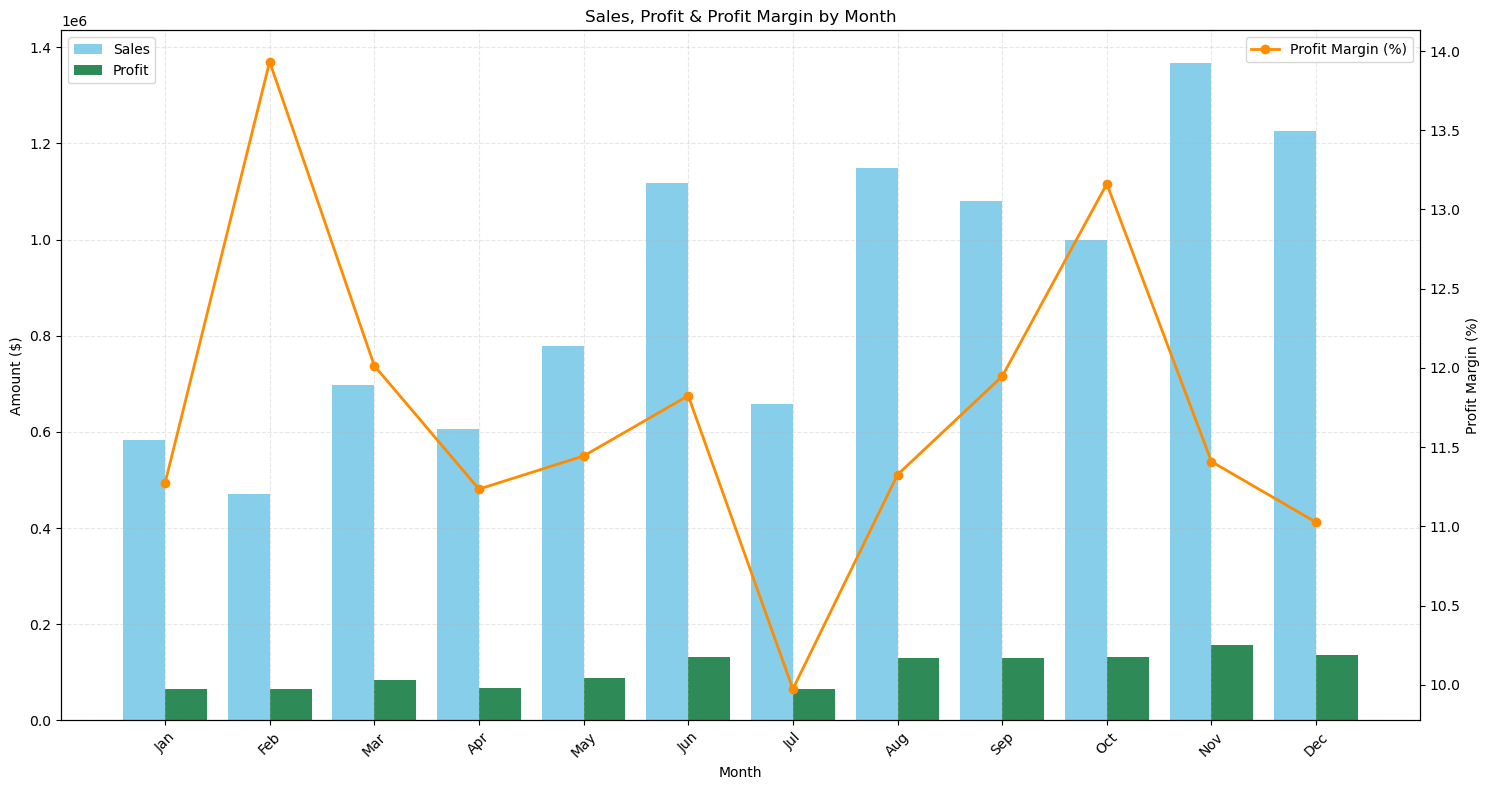

In [23]:
# bar chart showing revenue profit and profit margin by month
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

monthly_summary['month_name'] = monthly_summary['month_name'].astype(str)

monthly_summary['month_name'] = pd.Categorical(monthly_summary['month_name'], categories=month_order, ordered=True)
monthly_summary = monthly_summary.sort_values('month_name')

fig, ax1 = plt.subplots(figsize = (15,8))

# bar chart: Sales and Profit
x = range(len(monthly_summary))


# Cột Sales và Profit
bar_width = 0.4
ax1.bar([i - bar_width/2 for i in x], monthly_summary['sales'], width=bar_width, label='Sales', color='skyblue')
ax1.bar([i + bar_width/2 for i in x], monthly_summary['profit'], width=bar_width, label='Profit', color='seagreen')

# Trục y trái
ax1.set_ylabel('Amount ($)')
ax1.set_xlabel('Month')
ax1.set_title('Sales, Profit & Profit Margin by Month')
ax1.set_xticks(x)
ax1.set_xticklabels(monthly_summary['month_name'], rotation=45)
ax1.legend(loc='upper left')
ax1.grid(True, linestyle='--', alpha=0.3)

# Trục y phải: Profit Margin
ax2 = ax1.twinx()
ax2.plot(x, monthly_summary['profit_margin'], color='darkorange', marker='o', label='Profit Margin (%)', linewidth=2)
ax2.set_ylabel('Profit Margin (%)')
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

#### **Analysis**:
- November is an ideal time to focus on marketing and sales strategies, thanks to high revenue and profit margins.
- Feb and Jun have low performance (low revenue and profit margin), need to consider reducing costs or increasing promotions to stimulate demand
- Revenue and profit margin tend to be correlated, but absolute profit does not increase proportionally with revenue, possibly due to increased operating costs or discounts during peak months.

#### **Ship Mode**

In [24]:
# revenue by Ship mode
shipmode_summary = df.groupby('ship_mode')[['sales','profit', 'quantity']].sum().reset_index().round(2)
shipmode_summary.head()

,ship_mode,sales,profit,quantity
0,First Class,1670092.0,186972.12,23641
1,Same Day,666956.0,76109.18,9222
2,Second Class,2279761.0,261406.64,31518
3,Standard Class,6111283.0,726867.15,86039


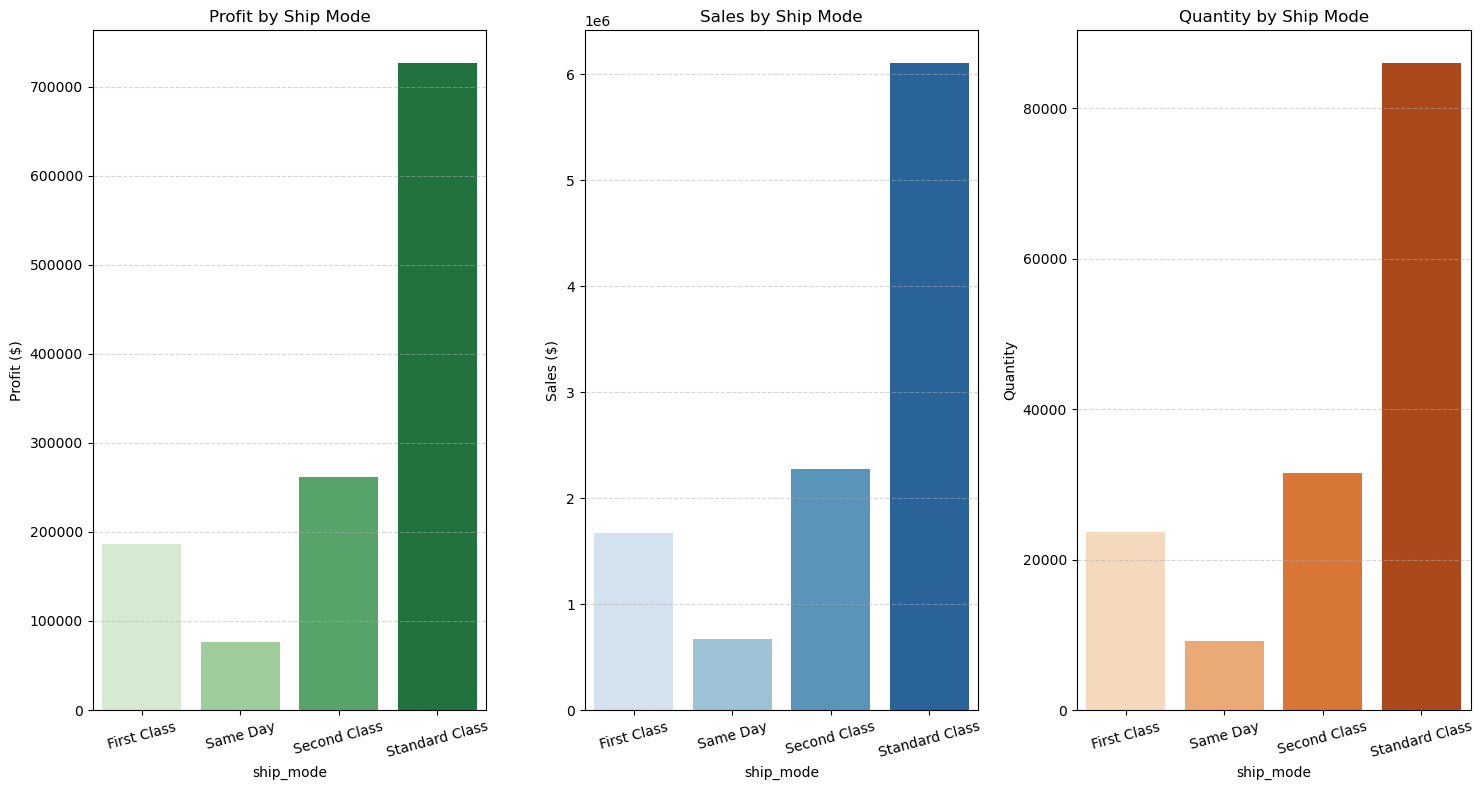

In [25]:
fig, axes = plt.subplots(1 , 3, figsize=(15, 8), sharex=False)

# chart 1: Profit
sns.barplot(data = shipmode_summary, x='ship_mode', y ='profit', palette='Greens', ax = axes[0])
axes[0].set_title('Profit by Ship Mode')
axes[0].set_ylabel('Profit ($)')
axes[0].tick_params(axis='x', rotation=15)
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

# chart 2: Sales
sns.barplot(data = shipmode_summary, x='ship_mode', y ='sales', palette='Blues', ax = axes[1])
axes[1].set_title('Sales by Ship Mode')
axes[1].set_ylabel('Sales ($)')
axes[1].tick_params(axis='x', rotation=15)
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

# chart 3: Quantity
sns.barplot(data = shipmode_summary, x='ship_mode', y ='quantity', palette='Oranges', ax = axes[2])
axes[2].set_title('Quantity by Ship Mode')
axes[2].set_ylabel('Quantity')
axes[2].tick_params(axis='x', rotation=15)
axes[2].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


#### **Segment**

In [26]:
segment_summary = df.groupby('segment')[['profit', 'sales', 'quantity']].sum().reset_index().round(2)

segment_summary.head()

,segment,profit,sales,quantity
0,Consumer,657586.52,5552161.0,77851
1,Corporate,362296.02,3222763.0,45214
2,Home Office,231472.55,1953168.0,27355


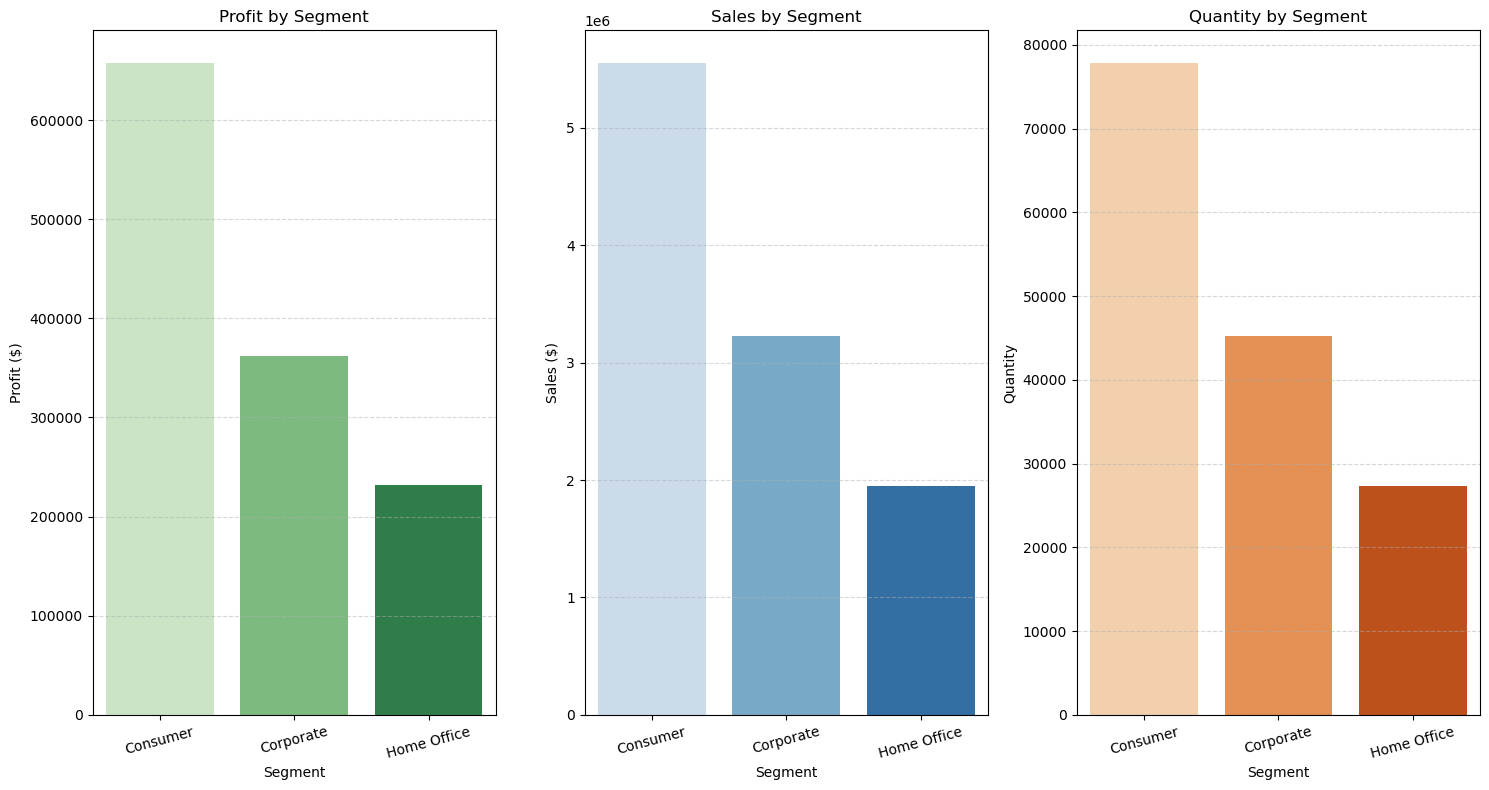

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(15, 8), sharex=False)

# chart 1: Profit
sns.barplot(data = segment_summary, x='segment', y ='profit', palette='Greens', ax = axes[0])
axes[0].set_title('Profit by Segment')
axes[0].set_ylabel('Profit ($)')
axes[0].set_xlabel('Segment')
axes[0].tick_params(axis='x', rotation=15)
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

# chart 2: Sales
sns.barplot(data = segment_summary, x='segment', y ='sales', palette='Blues', ax = axes[1])
axes[1].set_title('Sales by Segment')
axes[1].set_ylabel('Sales ($)')
axes[1].set_xlabel('Segment')
axes[1].tick_params(axis='x', rotation=15)
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

# chart 3: Quantity
sns.barplot(data = segment_summary, x='segment', y ='quantity', palette='Oranges', ax = axes[2])
axes[2].set_title('Quantity by Segment')
axes[2].set_ylabel('Quantity')
axes[2].set_xlabel('Segment')
axes[2].tick_params(axis='x', rotation=15)
axes[2].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


#### **Region**

In [28]:
#revenue by region
region_summary = df.groupby('region')[['sales', 'profit', 'quantity']].sum().reset_index().round(2)
region_summary.head()


,region,sales,profit,quantity
0,Africa,674453.0,76701.03,9051
1,Canada,61116.0,16428.63,756
2,Caribbean,281302.0,34235.20,5417
3,Central,2365489.0,261854.29,34795
4,Central Asia,639132.0,113172.43,6406


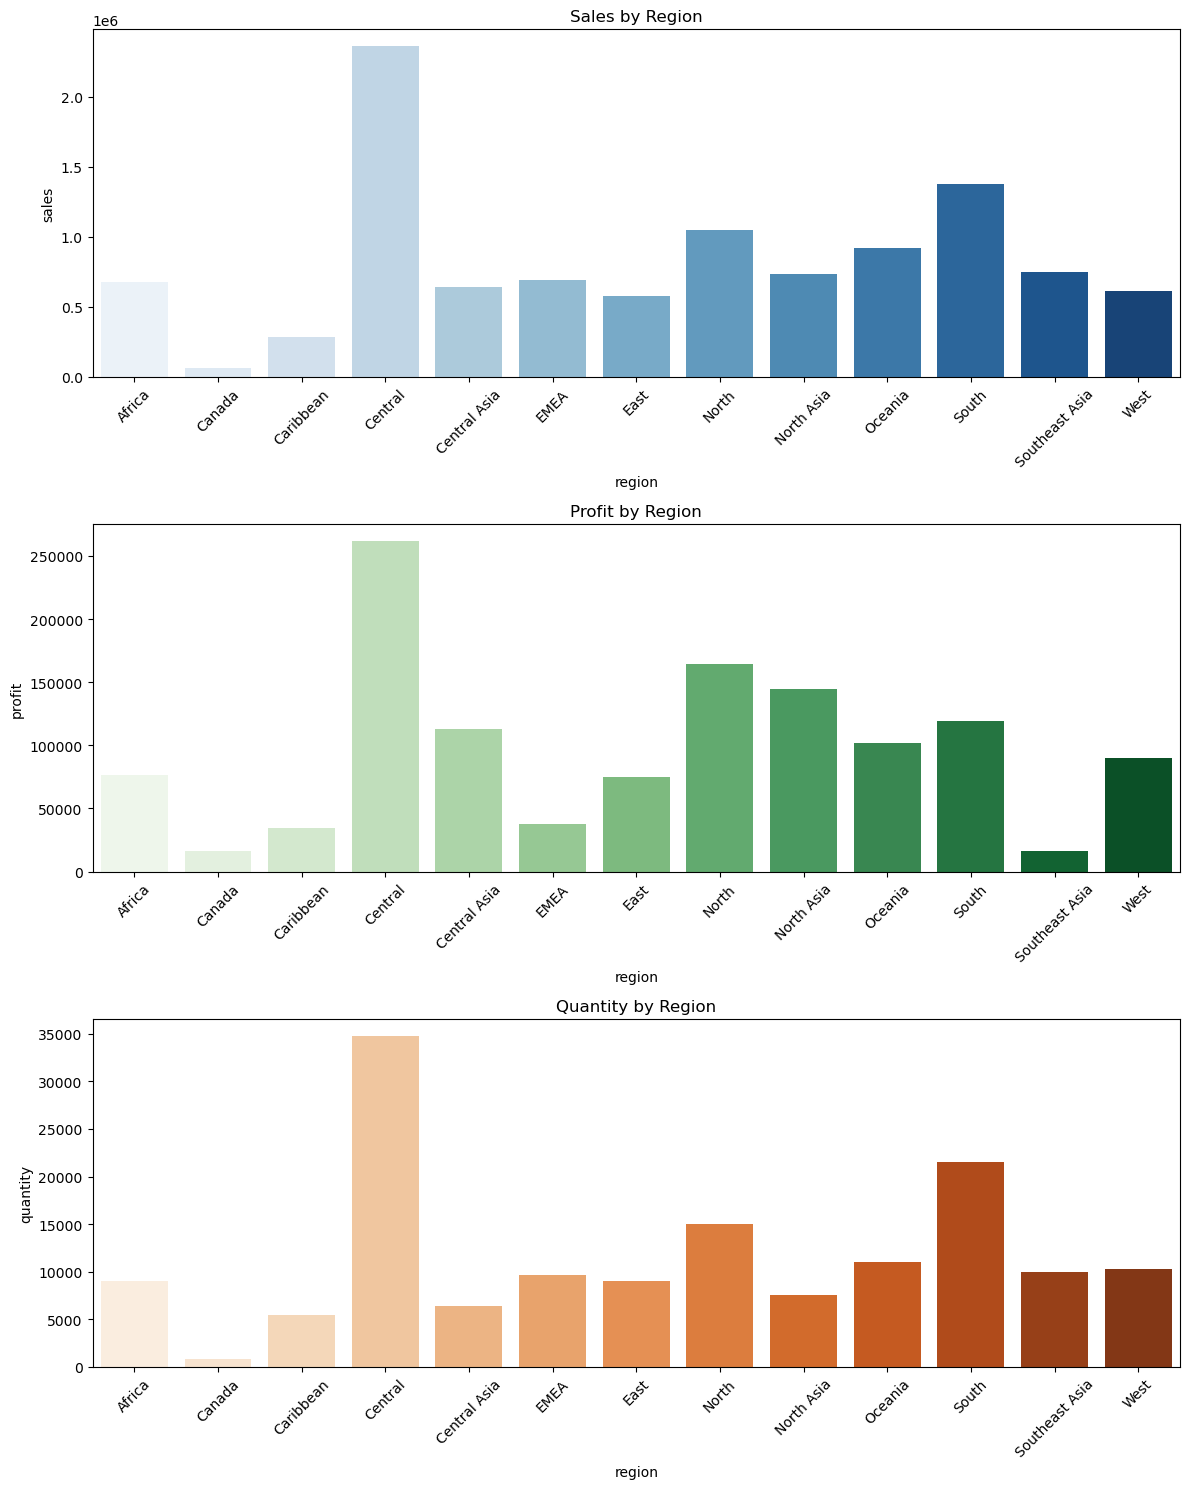

In [29]:
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(12, 15))

sns.barplot(data=region_summary, x='region', y='sales', ax=axes[0], palette='Blues')
axes[0].set_title('Sales by Region')
axes[0].tick_params(axis='x', rotation=45)

sns.barplot(data=region_summary, x='region', y='profit', ax=axes[1], palette='Greens')
axes[1].set_title('Profit by Region')
axes[1].tick_params(axis='x', rotation=45)

sns.barplot(data=region_summary, x='region', y='quantity', ax=axes[2], palette='Oranges')
axes[2].set_title('Quantity by Region')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

#### **Category**

In [30]:
category_summary = df.groupby('category')[['sales','profit','quantity']].sum().reset_index().round(2)
category_summary

,category,sales,profit,quantity
0,Furniture,3483421.0,248154.52,29348
1,Office Supplies,3225435.0,437315.22,91339
2,Technology,4019236.0,565885.34,29733


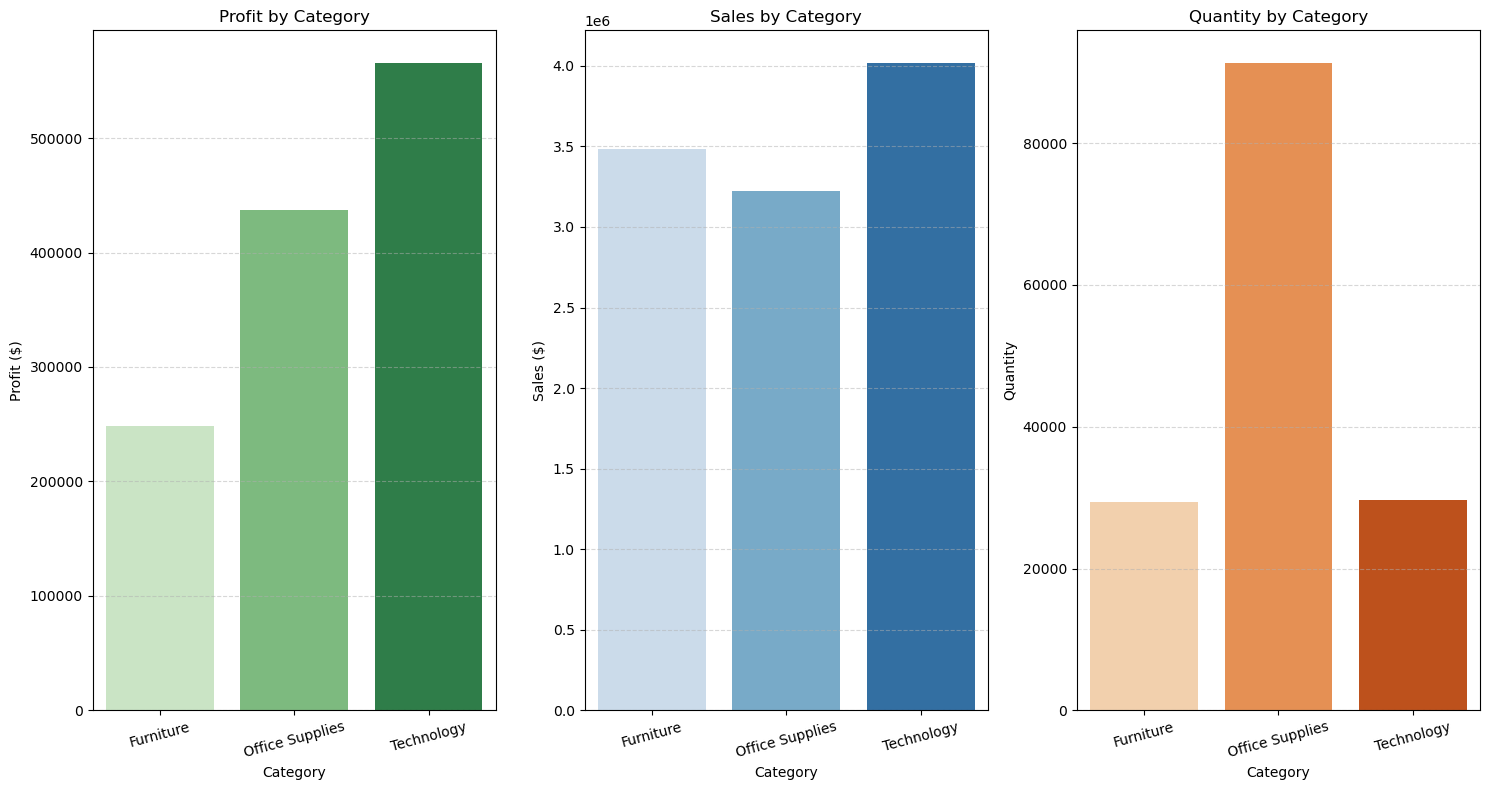

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(15, 8), sharex=False)

# chart 1: Profit
sns.barplot(data = category_summary, x='category', y ='profit', palette='Greens', ax = axes[0])
axes[0].set_title('Profit by Category')
axes[0].set_ylabel('Profit ($)')
axes[0].set_xlabel('Category')
axes[0].tick_params(axis='x', rotation=15)
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

# chart 2: Sales
sns.barplot(data = category_summary, x='category', y ='sales', palette='Blues', ax = axes[1])
axes[1].set_title('Sales by Category')
axes[1].set_ylabel('Sales ($)')
axes[1].set_xlabel('Category')
axes[1].tick_params(axis='x', rotation=15)
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

# chart 3: Quantity
sns.barplot(data = category_summary, x='category', y ='quantity', palette='Oranges', ax = axes[2])
axes[2].set_title('Quantity by Category')
axes[2].set_ylabel('Quantity')
axes[2].set_xlabel('Category')
axes[2].tick_params(axis='x', rotation=15)
axes[2].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [32]:
#sub-category
subcategory_summary = df.groupby('sub_category').agg({
    'sales': 'sum',
    'profit': 'sum',
    'quantity': 'sum',
    'order_id': 'nunique'}).round(2)
subcategory_summary.rename(columns={'order_id': 'Num_orders'}, inplace=True)
subcategory_summary


,sales,profit,quantity,Num_orders
sub_category,,,,
Accessories,635279.0,111043.62,9203,2432
Appliances,859658.0,113029.64,5209,1436
Art,315239.0,48734.99,13801,3693
Binders,395904.0,67909.21,17948,4561
Bookcases,1228119.0,138476.43,6889,1904
Chairs,1290234.0,123131.26,10444,2696
Copiers,1250209.0,209979.90,6298,1789
Envelopes,144691.0,24702.10,7103,1954
Fasteners,69524.0,9640.01,6989,1924


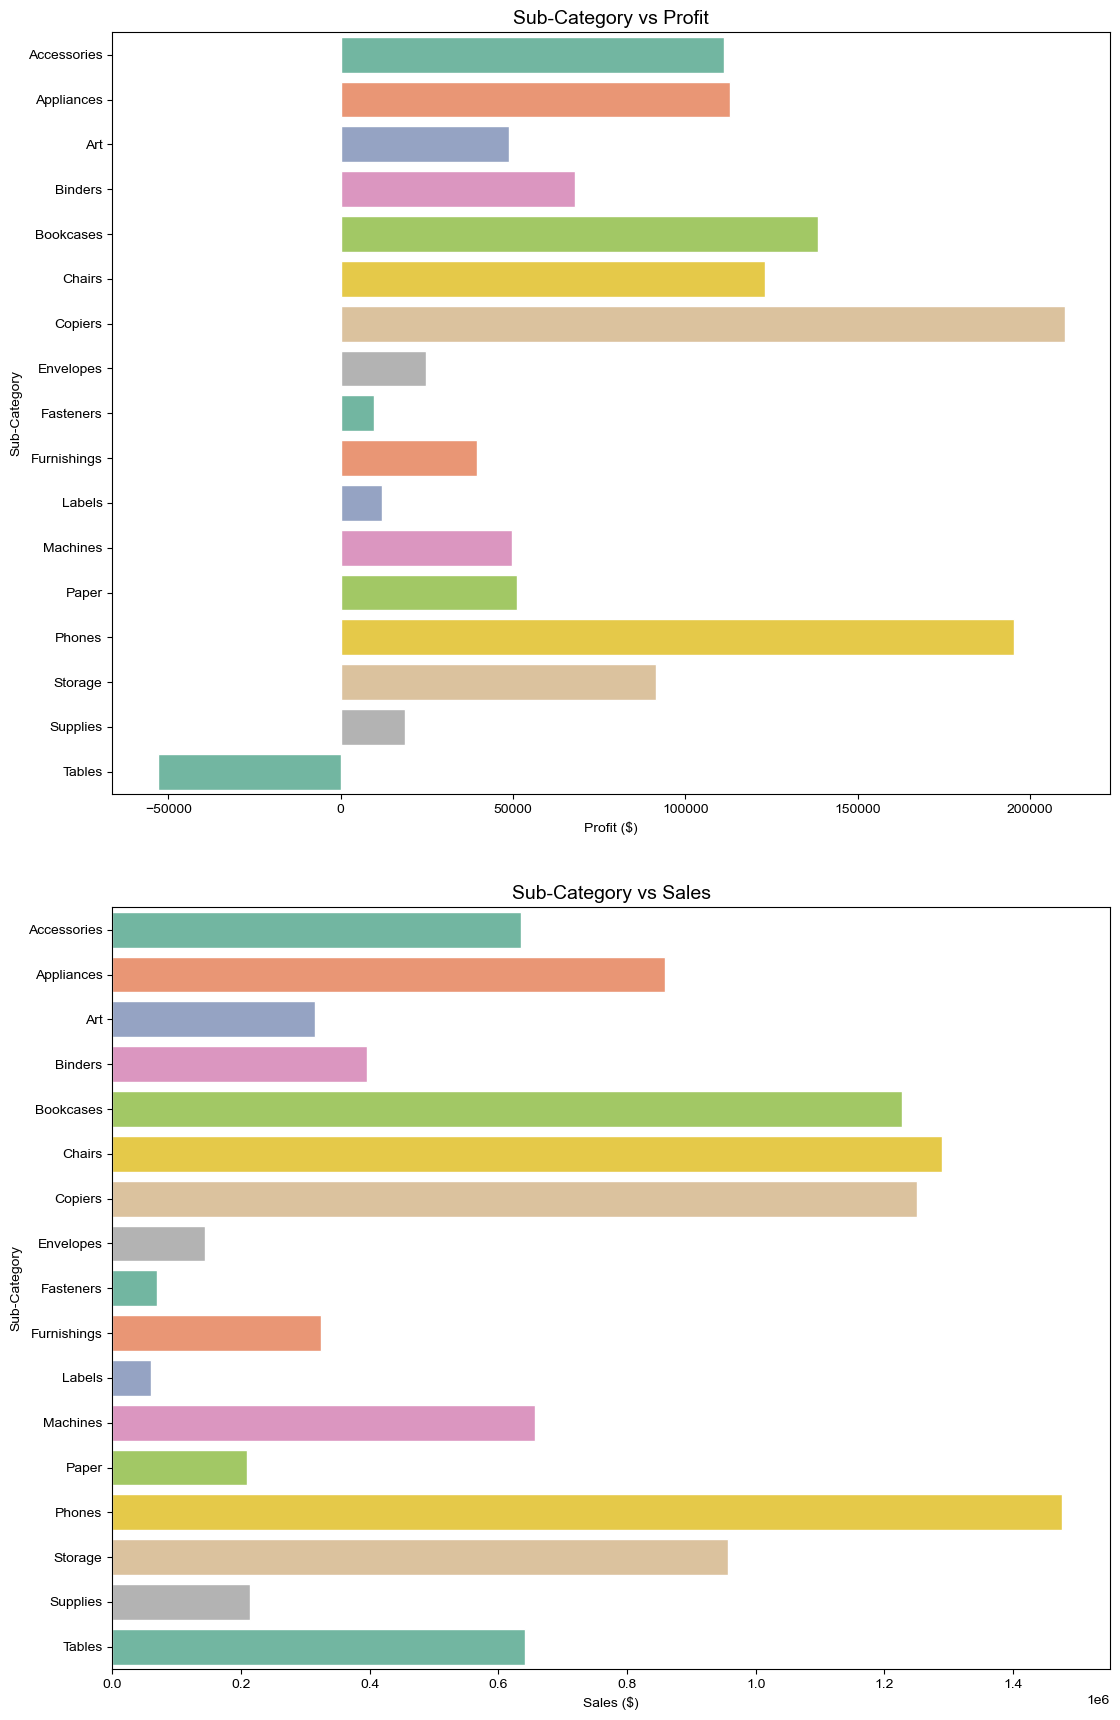

In [33]:
fig, axes = plt.subplots(2, 1, figsize=(12, 18))
sns.set_theme(style="darkgrid")

# Biểu đồ 1: Profit
sns.barplot(
    y=subcategory_summary.index,
    x='profit',
    data=subcategory_summary,
    palette='Set2',
    ax=axes[0]
)
axes[0].set_title("Sub-Category vs Profit", fontsize=14)
axes[0].set_xlabel("Profit ($)")
axes[0].set_ylabel("Sub-Category")

# Biểu đồ 2: Sales
sns.barplot(
    y=subcategory_summary.index,
    x='sales',
    data=subcategory_summary,
    palette='Set2',
    ax=axes[1]
)
axes[1].set_title("Sub-Category vs Sales", fontsize=14)
axes[1].set_xlabel("Sales ($)")
axes[1].set_ylabel("Sub-Category")

# Tối ưu bố cục
plt.tight_layout(pad=3)
plt.show()

#### **Customer**

In [34]:
# revenue by customer
top_customers = df.groupby('customer_name')[['sales', 'profit']].sum().reset_index().round(2)

top10_sales = top_customers.sort_values('sales', ascending=False).head(10)

top10_profit = top_customers.sort_values('profit', ascending=False).head(10)

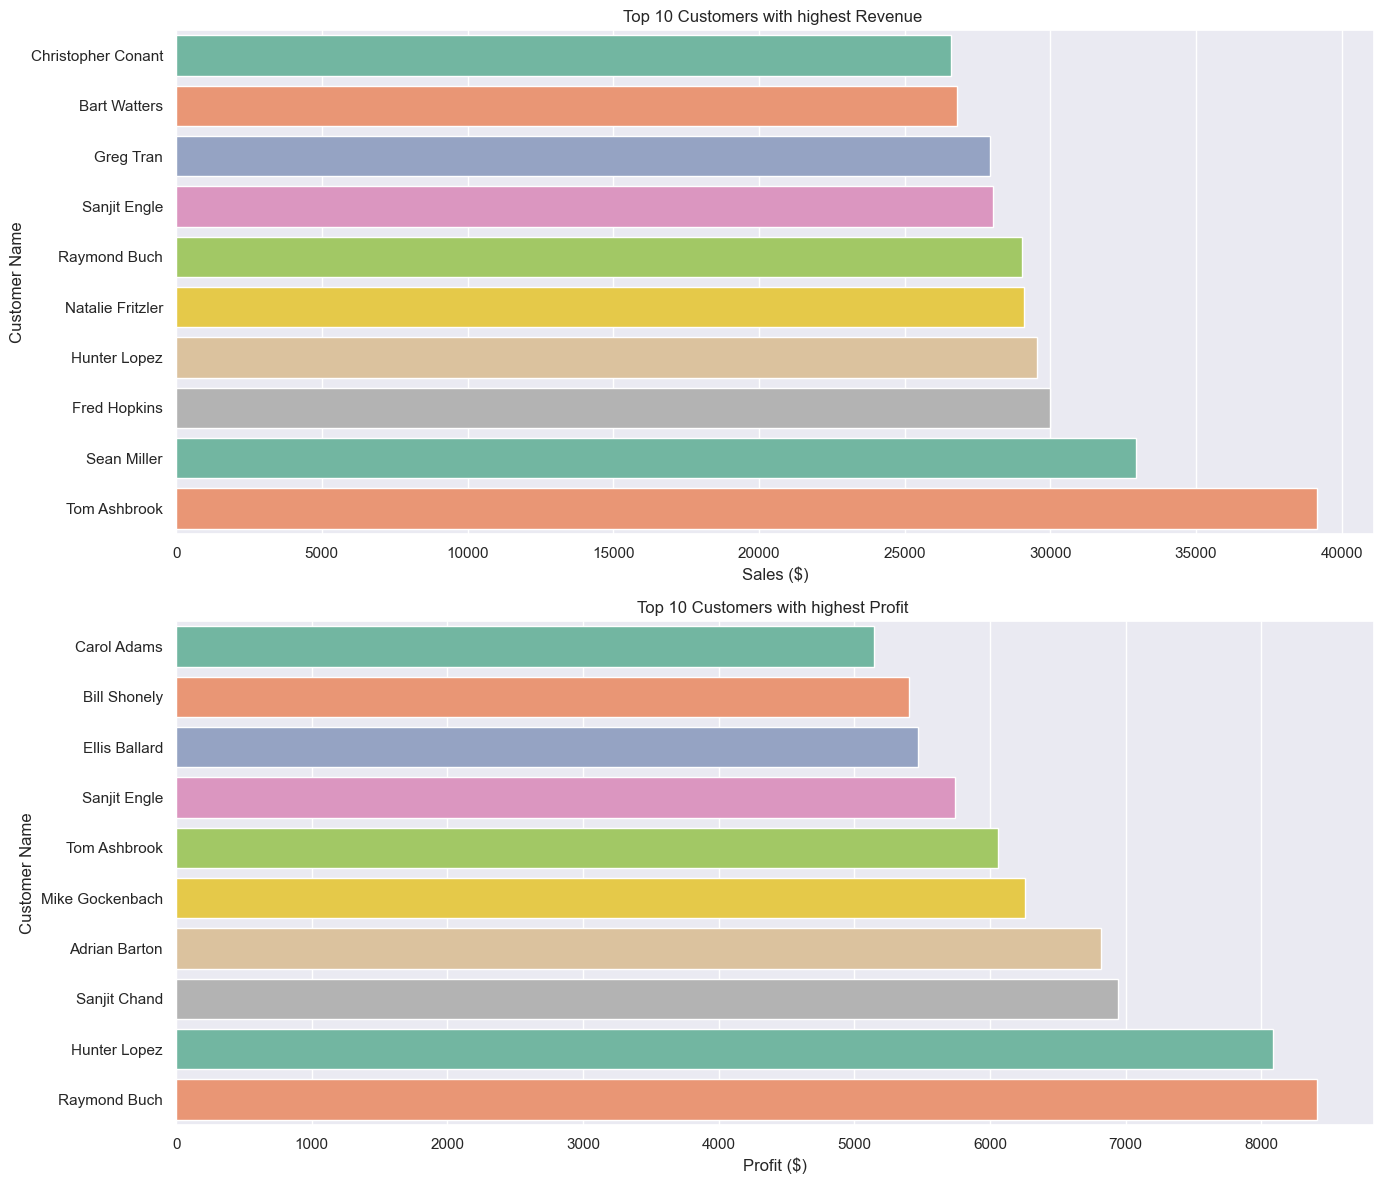

In [35]:
fig, axes = plt.subplots(2 ,1 , figsize=(14, 12))
sns.set_theme(style="darkgrid")

# chart 1 : top 10 customers by Sales
sns.barplot(
    data = top10_sales.sort_values('sales'),
    x = 'sales',
    y = 'customer_name',
    palette='Set2',
    ax = axes[0]
)
axes[0].set_title('Top 10 Customers with highest Revenue ')
axes[0].set_xlabel('Sales ($)')
axes[0].set_ylabel('Customer Name')

# chart 2: top 10 customers by Profit
sns.barplot(
    data = top10_profit.sort_values('profit'),
    x = 'profit',
    y = 'customer_name',
    palette='Set2',
    ax = axes[1]
)
axes[1].set_title('Top 10 Customers with highest Profit ')
axes[1].set_xlabel('Profit ($)')
axes[1].set_ylabel('Customer Name')

plt.tight_layout()
plt.show()

#### **Sales by Country**

In [36]:
country_sales = df.groupby('country')['sales'].sum().reset_index()

fig = px.choropleth(
    country_sales,
    locations='country',
    locationmode='country names',
    color='sales',
    color_continuous_scale='Blues',
    title='Revenue by Country',
    width=800,   
    height=500
)
fig.show()

### **5. Clustering Customer**

In [37]:
customer_summary = df.groupby('customer_name').agg({
    'sales': 'sum',
    'profit': 'sum',
    'discount' : 'mean',
    'order_id' : 'nunique'
}).reset_index()

customer_summary.columns = ['customer_name', 'total_sales', 'total_profit', 'avg_discount', 'order_count']
customer_summary.head()                      
                            

,customer_name,total_sales,total_profit,avg_discount,order_count
0,Aaron Bergman,21089.0,4338.84370,0.106154,34
1,Aaron Hawkins,17042.0,1554.74294,0.187489,29
2,Aaron Smayling,8137.0,-451.62920,0.207660,28
3,Adam Bellavance,17495.0,4619.45250,0.139048,38
4,Adam Hart,18237.0,874.22350,0.113478,35


In [38]:
# Standardize feature

features = ['total_sales', 'total_profit', 'avg_discount', 'order_count']
X = customer_summary[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

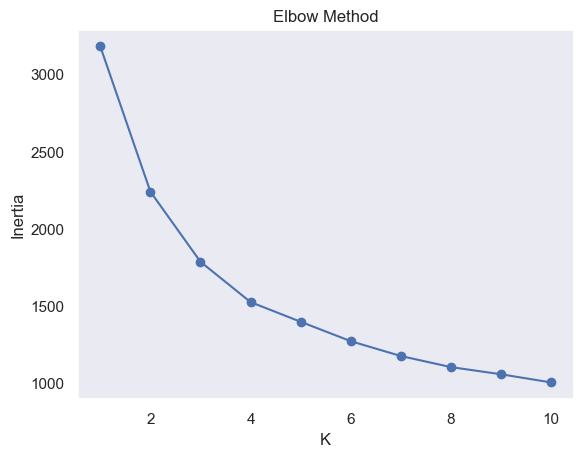

In [39]:
# Kmeans Clustering
inertia = []
for k in range (1, 11):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertia.append(km.inertia_)
    
plt.plot(range(1, 11), inertia, marker= 'o')
plt.title('Elbow Method')
plt.xlabel('K')
plt.ylabel('Inertia')
plt.grid()
plt.show()

In [40]:
kmeans = KMeans(n_clusters=4, random_state=42)
customer_summary['cluster'] = kmeans.fit_predict(X_scaled)

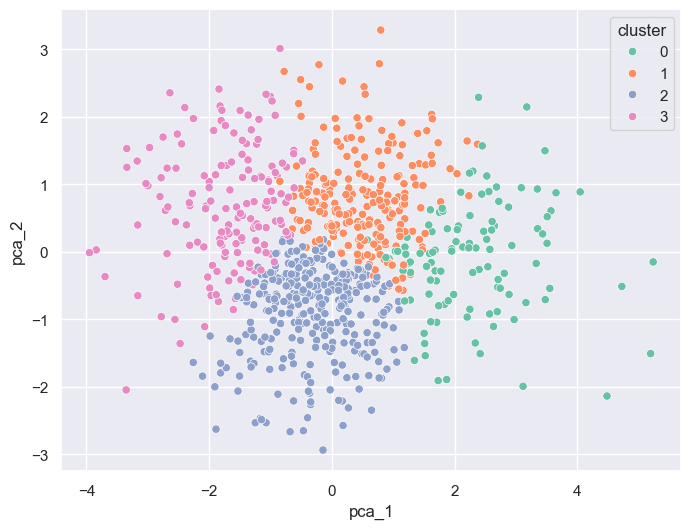

In [41]:
# visualize customer clusters
pca = PCA(n_components=2)
components = pca.fit_transform(X_scaled)
customer_summary['pca_1'] = components[:, 0]
customer_summary['pca_2'] = components[: , 1]

plt.figure(figsize=(8, 6))
sns.scatterplot(data = customer_summary, x='pca_1', y='pca_2', hue = 'cluster',palette='Set2' )
plt.show()

- Green cluster (0): High-spending customer group, great potential, need to prioritize retention to maximize profits.
- Orange cluster (1): Average customer group, major contributor to revenue, need to maintain and expand interactions.
- Blue cluster (2): Low/average shopping group, need to improve experience or encourage to increase efficiency.
- Pink cluster (3): Special group, less popular, need in-depth research to exploit potential or adjust strategy.

### **6.Model Predict Profit**

#### **Data Preprocessing**

In [42]:
features = ['sales', 'discount', 'quantity', 'shipping_cost', 'category',
            'sub_category', 'ship_mode', 'segment', 'region', 'market']

target = 'profit'

In [43]:
X = df[features]
y=df[target]

X = pd.get_dummies(X, drop_first=True) #one hot encoding

In [44]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#### **Linear Regression**

In [45]:
lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

In [46]:
y_pred_lr = lr.predict(X_test)
mae = mean_absolute_error(y_test, y_pred_lr)
mse = mean_squared_error(y_test, y_pred_lr)
r2 = r2_score(y_test, y_pred_lr)

print(f'Mean Absolute Error: {mae}')
print(f'Mean Squared Error: {mse}')
print(f'R-squared: {r2}')

Mean Absolute Error: 58.27921888405725
Mean Squared Error: 21434.887830361306
R-squared: 0.1904816119727376


#### **Random Forest Regressor**

In [47]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [48]:
y_pred_rf = rf.predict(X_test)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f'Mean Absolute Error: {mae_rf}')
print(f'Mean Squared Error: {mse_rf}')
print(f'R-squared: {r2_rf}')

Mean Absolute Error: 33.07149467388772
Mean Squared Error: 8111.746597596821
R-squared: 0.6936485937439346


#### **XGBoots Regressor**

In [49]:
xgb = XGBRegressor(n_estimators=100, random_state=42)
xgb.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [50]:
y_pred_xgb = xgb.predict(X_test)
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

print(f'Mean Absolute Error: {mae_xgb}')
print(f'Mean Squared Error: {mse_xgb}')
print(f'R-squared: {r2_xgb}')

Mean Absolute Error: 33.83655959510278
Mean Squared Error: 8021.764844531116
R-squared: 0.6970468799523859


### **7. Mode Predict Profit or Loss Order**

#### **Data Preprocessing**

In [51]:
df['is_profit'] = (df['profit'] > 0).astype(int)

In [52]:
features = ['sales', 'discount', 'quantity', 'shipping_cost', 'category',
            'sub_category', 'ship_mode', 'segment', 'region', 'market']
X = pd.get_dummies(df[features], drop_first=True)
y = df['is_profit']

In [53]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#### **Logistic Regression**

In [54]:
logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [55]:
y_pred_log = logreg.predict(X_test)

print("Accuracy (LogReg):", accuracy_score(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))

Accuracy (LogReg): 0.9227567067530065
              precision    recall  f1-score   support

           0       0.91      0.77      0.83      2139
           1       0.93      0.97      0.95      6509

    accuracy                           0.92      8648
   macro avg       0.92      0.87      0.89      8648
weighted avg       0.92      0.92      0.92      8648



#### **Desision Tree**

In [56]:
dt = DecisionTreeClassifier(random_state=42, max_depth=6)
dt.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=6, random_state=42)

In [57]:
y_pred_dt = dt.predict(X_test)

print("Accuracy (Decision Tree):", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

Accuracy (Decision Tree): 0.9240286771507863
              precision    recall  f1-score   support

           0       0.91      0.77      0.83      2139
           1       0.93      0.97      0.95      6509

    accuracy                           0.92      8648
   macro avg       0.92      0.87      0.89      8648
weighted avg       0.92      0.92      0.92      8648

